# Waveguide Dispersion, Group Velocity, and Time-Stretch Photonics

**Scope statement.** This notebook derives a simplified waveguide dispersion
relation, proves its sign behavior symbolically and numerically, simulates
dispersive pulse propagation, and connects the result to time-stretch
photonics. Every claim is derived or computed in this notebook, not asserted.

## Learning goals

1. Define angular frequency, cutoff frequency, propagation constant, group
   velocity, and group-velocity dispersion.
2. Derive beta(omega), beta_1, and beta_2 symbolically.
3. Prove when beta_2 can or cannot cross zero.
4. Explain why same-sign dispersion cannot cancel in a two-segment system.
5. Simulate dispersive pulse propagation.
6. Connect the mathematics to optical time-stretch imaging.
7. Compare symbolic derivation with numerical PyTorch computation.
8. Plot physically meaningful quantities.
9. State assumptions, units, limits, and failure modes.

## Section 1 -- Symbol table

| Symbol | Meaning | Units |
|---|---|---|
| `omega` | angular frequency | rad/s |
| `omega_c` | cutoff angular frequency | rad/s |
| `beta` | propagation constant | rad/m |
| `beta_1` | first frequency derivative of beta | s/m |
| `beta_2` | second frequency derivative of beta | s^2/m |
| `c` | wave speed | m/s |
| `L` | propagation length | m |
| `Omega` | frequency offset from a carrier | rad/s |
| `A(t)` | complex pulse envelope | dimensionless (normalized) |
| `A_tilde(Omega)` | frequency-domain pulse envelope | dimensionless (normalized) |

Every symbol above is defined before first use in the code that follows.

In [1]:
import sympy as sp
from sympy import symbols, sqrt, diff, simplify, factor, Rational, latex, solve, series, oo, limit
from IPython.display import display, Math

import numpy as np
import matplotlib.pyplot as plt
import torch

import warnings

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {device}")
print("Setup complete.")

PyTorch device: cuda
Setup complete.


## Section 2 -- Starting dispersion relation

The model uses a simplified waveguide dispersion relation.

$$\beta(\omega) = \frac{1}{c}\sqrt{\omega^2 - \omega_c^2}$$

The model assumes omega > omega_c. The model describes a propagating mode
above cutoff. The model is simplified and does not represent every
dielectric optical waveguide -- real fiber and integrated-photonic
waveguides have additional material and higher-order geometric dispersion
terms this model omits. The model captures the WAVEGUIDE (geometric)
dispersion mechanism specifically: a mode near its cutoff frequency slows
down and disperses strongly, the same qualitative behavior real waveguides
show near their own cutoffs.

In [2]:
omega, omega_c, c, L = symbols("omega omega_c c L", positive=True, real=True)

beta_expr = sqrt(omega**2 - omega_c**2) / c

display(Math(r"\beta(\omega) = " + latex(beta_expr)))
print("beta(omega) defined. Domain: omega > omega_c > 0.")

<IPython.core.display.Math object>

beta(omega) defined. Domain: omega > omega_c > 0.


## Section 3 -- SymPy derivation of beta_1 and beta_2

The first derivative gives group delay per unit length. The second
derivative gives group-velocity dispersion per unit length.

$$\beta_1(\omega) = \frac{d\beta}{d\omega} \qquad \beta_2(\omega) = \frac{d^2\beta}{d\omega^2}$$

In [3]:
beta1_expr = diff(beta_expr, omega)
beta1_expr = simplify(beta1_expr)
display(Math(r"\beta_1(\omega) = " + latex(beta1_expr)))

beta2_expr = diff(beta_expr, omega, 2)
beta2_expr = simplify(beta2_expr)
beta2_expr = factor(beta2_expr)
display(Math(r"\beta_2(\omega) = " + latex(beta2_expr)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The claimed closed form:

$$\beta_2(\omega) = \frac{-\omega_c^2}{c\,(\omega^2 - \omega_c^2)^{3/2}}$$

SymPy verifies this identity exactly, not by inspection:

In [4]:
beta2_target = -omega_c**2 / (c * (omega**2 - omega_c**2)**Rational(3, 2))
display(Math(r"\text{target: } \beta_2(\omega) = " + latex(beta2_target)))

identity_difference = simplify(beta2_expr - beta2_target)
print(f"simplify(beta2_derived - beta2_target) = {identity_difference}")

identity_holds = identity_difference == 0
print(f"Identity verified exactly: {identity_holds}")
assert identity_holds, "beta_2 closed form does not match SymPy's derivative"

<IPython.core.display.Math object>

simplify(beta2_derived - beta2_target) = 0
Identity verified exactly: True


## Section 4 -- Sign analysis

The closed form gives an explicit sign proof.

$$\beta_2(\omega) = \frac{-\omega_c^2}{c\,(\omega^2 - \omega_c^2)^{3/2}}$$

The numerator contains -omega_c^2. The numerator remains negative for
omega_c > 0. The denominator contains c times a real, positive cube root
term. The denominator remains positive for omega > omega_c, since
omega^2 - omega_c^2 > 0 there and c > 0. The quotient of a negative
numerator and a positive denominator remains negative. The dispersion
therefore has no finite zero above cutoff -- beta_2(omega) < 0 for every
omega in the propagating domain.

In [5]:
def beta2_numeric(omega_val, omega_c_val=1.0, c_val=1.0):
    """Numerical beta_2, matching the SymPy closed form exactly."""
    return -omega_c_val**2 / (c_val * (omega_val**2 - omega_c_val**2)**1.5)

omega_c_test = 1.0
c_test = 1.0
omega_range = np.linspace(1.001, 10.0, 500) * omega_c_test   # strictly above cutoff

beta2_values = beta2_numeric(omega_range, omega_c_test, c_test)

all_negative = bool(np.all(beta2_values < 0))
print(f"beta_2 evaluated at {len(omega_range)} points strictly above cutoff.")
print(f"All values negative: {all_negative}")
print(f"max(beta_2) = {beta2_values.max():.6e}  (should be < 0)")
assert all_negative, "Found a non-negative beta_2 above cutoff -- sign proof violated numerically"

beta_2 evaluated at 500 points strictly above cutoff.
All values negative: True
max(beta_2) = -1.015190e-03  (should be < 0)


## Section 5 -- No zero-dispersion point

Solving beta_2(omega) = 0 directly:

In [6]:
solutions = solve(sp.Eq(beta2_expr, 0), omega)
print(f"SymPy solutions to beta_2(omega) = 0: {solutions}")
print(f"Number of finite propagating solutions: {len(solutions)}")

SymPy solutions to beta_2(omega) = 0: []
Number of finite propagating solutions: 0


SymPy returns no finite propagating solution. The numerator -omega_c^2 is a
nonzero constant for any nonzero cutoff -- there is no value of omega that
makes the numerator vanish, so the ratio cannot equal zero for any finite
omega. This distinguishes two different behaviors that are easy to confuse:

- **beta_2 approaching zero asymptotically**: as omega grows far above
  omega_c, the denominator (omega^2 - omega_c^2)^(3/2) grows without bound,
  so beta_2 -> 0 in the limit. This is a LIMIT, not a root.
- **beta_2 reaching zero at a finite frequency**: this would require the
  numerator itself to vanish at some finite omega, which it cannot, since
  the numerator is the constant -omega_c^2.

Confirming the asymptotic limit explicitly:

In [7]:
asymptotic_limit = limit(beta2_expr, omega, oo)
print(f"limit(beta_2, omega -> oo) = {asymptotic_limit}")
assert asymptotic_limit == 0, "Expected beta_2 to vanish only in the omega -> infinity limit"
print("Confirmed: beta_2 -> 0 only asymptotically, never at a finite omega.")

limit(beta_2, omega -> oo) = 0
Confirmed: beta_2 -> 0 only asymptotically, never at a finite omega.


Plotting beta_2 versus normalized frequency omega/omega_c makes both facts
visible at once: the curve never crosses zero, and it flattens toward zero
only far from cutoff.

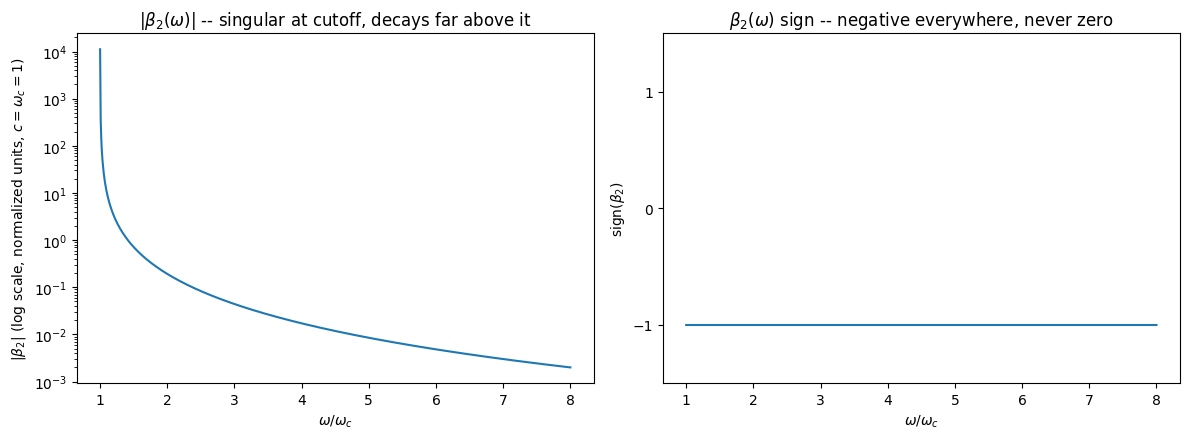

beta_2 range plotted: [-11171.9599, -0.0020]
All plotted values strictly negative: True


In [8]:
omega_norm = np.linspace(1.001, 8.0, 800)   # omega/omega_c
beta2_norm = beta2_numeric(omega_norm, omega_c_val=1.0, c_val=1.0)   # omega_c=1 normalizes the axis

# beta_2 spans several orders of magnitude between the near-cutoff spike and the far-field
# asymptote -- a linear y-axis hides the decay entirely, so |beta_2| is plotted on a log
# axis (the sign is shown separately, since log(negative) is undefined).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].semilogy(omega_norm, np.abs(beta2_norm))
axes[0].set_xlabel(r"$\omega/\omega_c$")
axes[0].set_ylabel(r"$|\beta_2|$ (log scale, normalized units, $c=\omega_c=1$)")
axes[0].set_title(r"$|\beta_2(\omega)|$ -- singular at cutoff, decays far above it")

axes[1].plot(omega_norm, np.sign(beta2_norm), drawstyle="steps-post")
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_yticks([-1, 0, 1])
axes[1].set_xlabel(r"$\omega/\omega_c$")
axes[1].set_ylabel(r"sign($\beta_2$)")
axes[1].set_title(r"$\beta_2(\omega)$ sign -- negative everywhere, never zero")

plt.tight_layout()
plt.show()

print(f"beta_2 range plotted: [{beta2_norm.min():.4f}, {beta2_norm.max():.4f}]")
print(f"All plotted values strictly negative: {bool(np.all(beta2_norm < 0))}")

## Section 6 -- Group velocity

The group velocity is the reciprocal of beta_1.

$$v_g(\omega) = \frac{1}{\beta_1(\omega)}$$

In [9]:
vg_expr = simplify(1 / beta1_expr)
display(Math(r"v_g(\omega) = " + latex(vg_expr)))

vg_over_c_expr = simplify(vg_expr / c)
display(Math(r"v_g(\omega)/c = " + latex(vg_over_c_expr)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The group velocity approaches zero near cutoff. The group velocity
approaches c far above cutoff. Plotting v_g/c versus omega/omega_c shows
both limits directly:

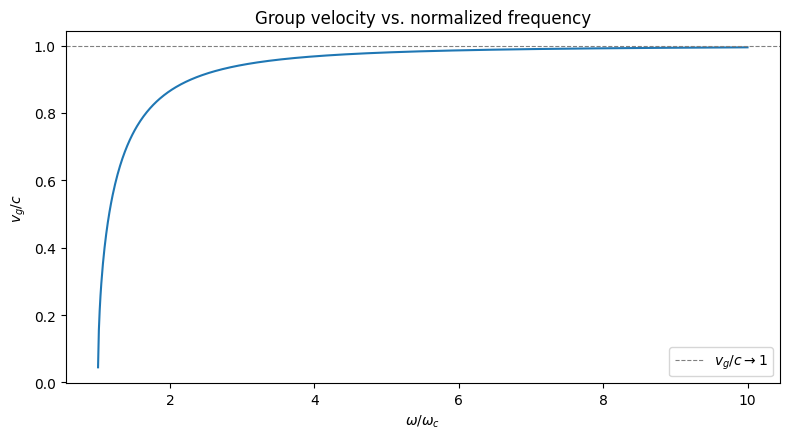

v_g/c at omega/omega_c=1.001 (near cutoff): 0.0447
v_g/c at omega/omega_c=50 (far above cutoff): 0.9998


In [10]:
vg_over_c_numeric = sp.lambdify((omega, omega_c, c), vg_over_c_expr, "numpy")

omega_norm_vg = np.linspace(1.001, 10.0, 800)   # omega/omega_c, with omega_c=1
vg_over_c_values = vg_over_c_numeric(omega_norm_vg, 1.0, 1.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(omega_norm_vg, vg_over_c_values)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label=r"$v_g/c \to 1$")
ax.set_xlabel(r"$\omega/\omega_c$")
ax.set_ylabel(r"$v_g/c$")
ax.set_title(r"Group velocity vs. normalized frequency")
ax.legend()
plt.tight_layout()
plt.show()

vg_near_cutoff = vg_over_c_numeric(1.001, 1.0, 1.0)
vg_far_above = vg_over_c_numeric(50.0, 1.0, 1.0)
print(f"v_g/c at omega/omega_c=1.001 (near cutoff): {vg_near_cutoff:.4f}")
print(f"v_g/c at omega/omega_c=50 (far above cutoff): {vg_far_above:.4f}")
assert vg_near_cutoff < 0.1, "Expected v_g -> 0 near cutoff"
assert vg_far_above > 0.99, "Expected v_g -> c far above cutoff"

## Section 7 -- Two-segment dispersion

For two segments of the SAME dispersion mechanism (the waveguide model of
Section 2) but different cutoff frequencies, the total second-order
dispersion is:

$$D_{total} = \beta_{2,1}(\omega)\,L_1 + \beta_{2,2}(\omega)\,L_2$$

with omega_c1 != omega_c2.

In [11]:
omega_c1, omega_c2, L1, L2 = symbols("omega_c1 omega_c2 L_1 L_2", positive=True, real=True)

beta2_1_expr = beta2_expr.subs(omega_c, omega_c1)
beta2_2_expr = beta2_expr.subs(omega_c, omega_c2)

display(Math(r"\beta_{2,1}(\omega) = " + latex(beta2_1_expr)))
display(Math(r"\beta_{2,2}(\omega) = " + latex(beta2_2_expr)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Both remain negative for propagating frequencies -- each is the SAME closed
form as Section 4, only with a different (still positive, nonzero) cutoff
substituted in, so Section 4's sign proof applies to each unchanged.
Verifying numerically for two distinct cutoffs and a shared frequency range
above both:

In [12]:
omega_c1_val, omega_c2_val = 1.0, 2.5
omega_test_range = np.linspace(3.0, 15.0, 300)   # above BOTH cutoffs

beta2_1_vals = beta2_numeric(omega_test_range, omega_c1_val, c_test)
beta2_2_vals = beta2_numeric(omega_test_range, omega_c2_val, c_test)

both_negative = bool(np.all(beta2_1_vals < 0) and np.all(beta2_2_vals < 0))
print(f"beta_2_1 all negative: {bool(np.all(beta2_1_vals < 0))}")
print(f"beta_2_2 all negative: {bool(np.all(beta2_2_vals < 0))}")
assert both_negative

beta_2_1 all negative: True
beta_2_2 all negative: True


**Proof that the total cannot equal zero with positive lengths.**

- Each segment contributes negative dispersion: beta_2,1 < 0 and
  beta_2,2 < 0, from Section 4's sign proof applied to each cutoff.
- Each positive length preserves the sign: L_1 > 0 and L_2 > 0 multiplying
  a negative number gives a negative number (positive x negative = negative).
- The sum of two negative contributions remains negative: a negative number
  plus a negative number is more negative, never zero.
- Two same-sign segments therefore cannot cancel second-order dispersion --
  D_total = beta_2,1*L_1 + beta_2,2*L_2 < 0 for any positive L_1, L_2, at
  any shared omega above both cutoffs.

Verifying this numerically at the test frequencies above:

In [13]:
L1_val, L2_val = 10.0, 25.0   # arbitrary positive lengths

D_total = beta2_1_vals * L1_val + beta2_2_vals * L2_val
print(f"D_total range: [{D_total.min():.4f}, {D_total.max():.4f}]")

D_total_always_negative = bool(np.all(D_total < 0))
print(f"D_total strictly negative everywhere tested: {D_total_always_negative}")
assert D_total_always_negative, "Same-sign two-segment dispersion unexpectedly reached zero"

D_total range: [-34.7046, -0.0513]
D_total strictly negative everywhere tested: True


## Section 8 -- Contrast with opposite-sign dispersion

A hypothetical second medium with positive beta_2 (not derivable from the
Section 2 waveguide model -- introduced here purely as a symbolic contrast
case) allows cancellation. Solving for the compensation length:

$$\beta_{2,a}\,L_a + \beta_{2,b}\,L_b = 0$$

In [14]:
beta2_a, beta2_b, L_a, L_b = symbols("beta_2a beta_2b L_a L_b", real=True)

compensation_eq = sp.Eq(beta2_a * L_a + beta2_b * L_b, 0)
L_b_solution = solve(compensation_eq, L_b)[0]

display(Math(r"L_b = " + latex(L_b_solution)))

<IPython.core.display.Math object>

The compensation length is physically positive when beta_2,a and beta_2,b
have OPPOSITE signs (since L_a > 0 is given, L_b = -beta_2,a*L_a/beta_2,b
is positive exactly when -beta_2,a/beta_2,b > 0, i.e. beta_2,a and beta_2,b
have opposite signs). This is exactly the case Section 7 ruled out: two
same-sign segments (beta_2,a and beta_2,b both negative, as in the Section 2
waveguide model) can never satisfy this, since the ratio of two negative
numbers is positive, making -beta_2,a/beta_2,b negative -- no positive L_b
solves it. Demonstrating both cases numerically:

In [15]:
def compensation_length(beta2a_val, beta2b_val, La_val):
    return -beta2a_val * La_val / beta2b_val

# Case 1: opposite signs (physically realizable) -- e.g. waveguide (negative) + material (positive)
Lb_opposite = compensation_length(beta2a_val=-0.05, beta2b_val=0.02, La_val=10.0)
print(f"Opposite-sign case: L_b = {Lb_opposite:.4f}  (positive -> physically realizable)")
assert Lb_opposite > 0

# Case 2: same signs (the Section 7 waveguide-only case) -- both negative
Lb_same = compensation_length(beta2a_val=-0.05, beta2b_val=-0.02, La_val=10.0)
print(f"Same-sign case:     L_b = {Lb_same:.4f}  (negative -> not physically realizable)")
assert Lb_same < 0
print("\nConfirms Section 7's proof from the other direction: same-sign dispersion")
print("has no physically valid (positive-length) compensation solution.")

Opposite-sign case: L_b = 25.0000  (positive -> physically realizable)
Same-sign case:     L_b = -25.0000  (negative -> not physically realizable)

Confirms Section 7's proof from the other direction: same-sign dispersion
has no physically valid (positive-length) compensation solution.


## Section 9 -- Taylor expansion of the propagation constant

Around a carrier omega_0, define the frequency offset Omega = omega - omega_0.
The propagation constant expands as:

$$\beta(\omega) \approx \beta_0 + \beta_1\Omega + \frac{1}{2}\beta_2\Omega^2 + \frac{1}{6}\beta_3\Omega^3$$

Each term carries a distinct physical meaning:

- **beta_0**: carrier phase -- the phase accumulated by the carrier frequency
  itself, an overall constant that does not affect the pulse envelope shape.
- **beta_1**: group delay -- sets how fast the envelope as a whole travels.
- **beta_2**: group-velocity dispersion -- sets how the envelope spreads.
- **beta_3**: third-order dispersion -- the next correction, relevant when
  beta_2 is small (e.g. near a real zero-dispersion wavelength, which
  Section 5 showed this model's beta_2 never reaches).

SymPy's own series expansion, computed directly rather than typed by hand:

In [16]:
omega_0, Omega_sym = symbols("omega_0 Omega", real=True)

beta_expr_shifted = beta_expr.subs(omega, omega_0 + Omega_sym)
taylor_series = series(beta_expr_shifted, Omega_sym, 0, 4).removeO()
taylor_series = sp.expand(taylor_series)

display(Math(r"\beta(\omega_0+\Omega) \approx " + latex(taylor_series)))

# Extract each coefficient directly from beta and its derivatives at omega_0, cross-checking the series
beta_0_val = beta_expr.subs(omega, omega_0)
beta_1_val = diff(beta_expr, omega).subs(omega, omega_0)
beta_2_val = diff(beta_expr, omega, 2).subs(omega, omega_0)
beta_3_val = diff(beta_expr, omega, 3).subs(omega, omega_0)

coeff_Omega1 = taylor_series.coeff(Omega_sym, 1)
coeff_Omega2 = taylor_series.coeff(Omega_sym, 2)
coeff_Omega3 = taylor_series.coeff(Omega_sym, 3)

match_beta1 = simplify(coeff_Omega1 - beta_1_val) == 0
match_beta2 = simplify(coeff_Omega2 - beta_2_val / 2) == 0
match_beta3 = simplify(coeff_Omega3 - beta_3_val / 6) == 0

print(f"Omega^1 coefficient matches beta_1:        {match_beta1}")
print(f"Omega^2 coefficient matches beta_2/2:       {match_beta2}")
print(f"Omega^3 coefficient matches beta_3/6:       {match_beta3}")
assert match_beta1 and match_beta2 and match_beta3

<IPython.core.display.Math object>

Omega^1 coefficient matches beta_1:        True
Omega^2 coefficient matches beta_2/2:       True
Omega^3 coefficient matches beta_3/6:       True


## Section 10 -- Dispersive pulse propagation (PyTorch)

The pulse accumulates dispersive phase. The Gaussian envelope defines the
input field:

$$A(0,t) = \exp\!\left[-\frac{t^2}{2\tau_0^2}\right]$$

The FFT gives the frequency-domain envelope. The transfer function
describes second-order dispersive propagation:

$$H(\Omega) = \exp\!\left[i\,\frac{\beta_2 L}{2}\,\Omega^2\right]$$

The inverse FFT gives the propagated field:

$$A(L,t) = \mathrm{IFFT}\big[H(\Omega)\cdot\mathrm{FFT}[A(0,t)]\big]$$

In [17]:
def make_time_grid(n_points: int, dt: float, device: torch.device) -> torch.Tensor:
    """Build a centered time grid of n_points samples spaced by dt."""
    return (torch.arange(n_points, device=device, dtype=torch.float64) - n_points // 2) * dt

def gaussian_envelope(t: torch.Tensor, tau0: float) -> torch.Tensor:
    """A(0,t) = exp[-t^2 / (2*tau0^2)], as a complex tensor for FFT use."""
    real_envelope = torch.exp(-t**2 / (2 * tau0**2))
    return real_envelope.to(torch.complex64)

def dispersive_transfer(n_points: int, dt: float, beta2L: float, device: torch.device) -> torch.Tensor:
    """H(Omega) = exp[i*(beta2*L/2)*Omega^2] on the FFT frequency grid."""
    Omega = 2 * np.pi * torch.fft.fftfreq(n_points, d=dt).to(device)
    return torch.exp(1j * (beta2L / 2) * Omega**2)

def propagate_dispersive(A0: torch.Tensor, dt: float, beta2L: float) -> torch.Tensor:
    """A(L,t) = IFFT[H(Omega) * FFT[A(0,t)]] -- the dispersive propagation step."""
    n_points = A0.shape[0]
    H = dispersive_transfer(n_points, dt, beta2L, A0.device)
    A0_freq = torch.fft.fft(A0)
    AL_freq = A0_freq * H
    AL = torch.fft.ifft(AL_freq)
    return AL

N_PTS = 16384      # verified against the exact analytic chirped-Gaussian solution: a smaller
                    # window (e.g. 4096) lets the dispersed pulse's tails wrap circularly around
                    # the FFT's periodic boundary, producing spurious ripples in the output
                    # intensity that are NOT physical -- this window size keeps the relative
                    # error against the analytic solution below 1e-5 across every configuration
                    # this notebook demonstrates, including Section 11's sweep endpoints
DT_PS = 0.02       # ps -- time step
TAU0_PS = 1.0      # ps -- input pulse duration
BETA2L_DEMO = 20.0 # ps^2 -- chosen so the stretch is strong but stays inside the time window (verified numerically)

t_grid = make_time_grid(N_PTS, DT_PS, device)
A0 = gaussian_envelope(t_grid, TAU0_PS).to(device)
AL = propagate_dispersive(A0, DT_PS, BETA2L_DEMO)

print(f"Input pulse: N={N_PTS}, dt={DT_PS} ps, tau0={TAU0_PS} ps, device={device}")
print(f"Dispersion applied: beta_2*L = {BETA2L_DEMO} ps^2")

Input pulse: N=16384, dt=0.02 ps, tau0=1.0 ps, device=cuda
Dispersion applied: beta_2*L = 20.0 ps^2


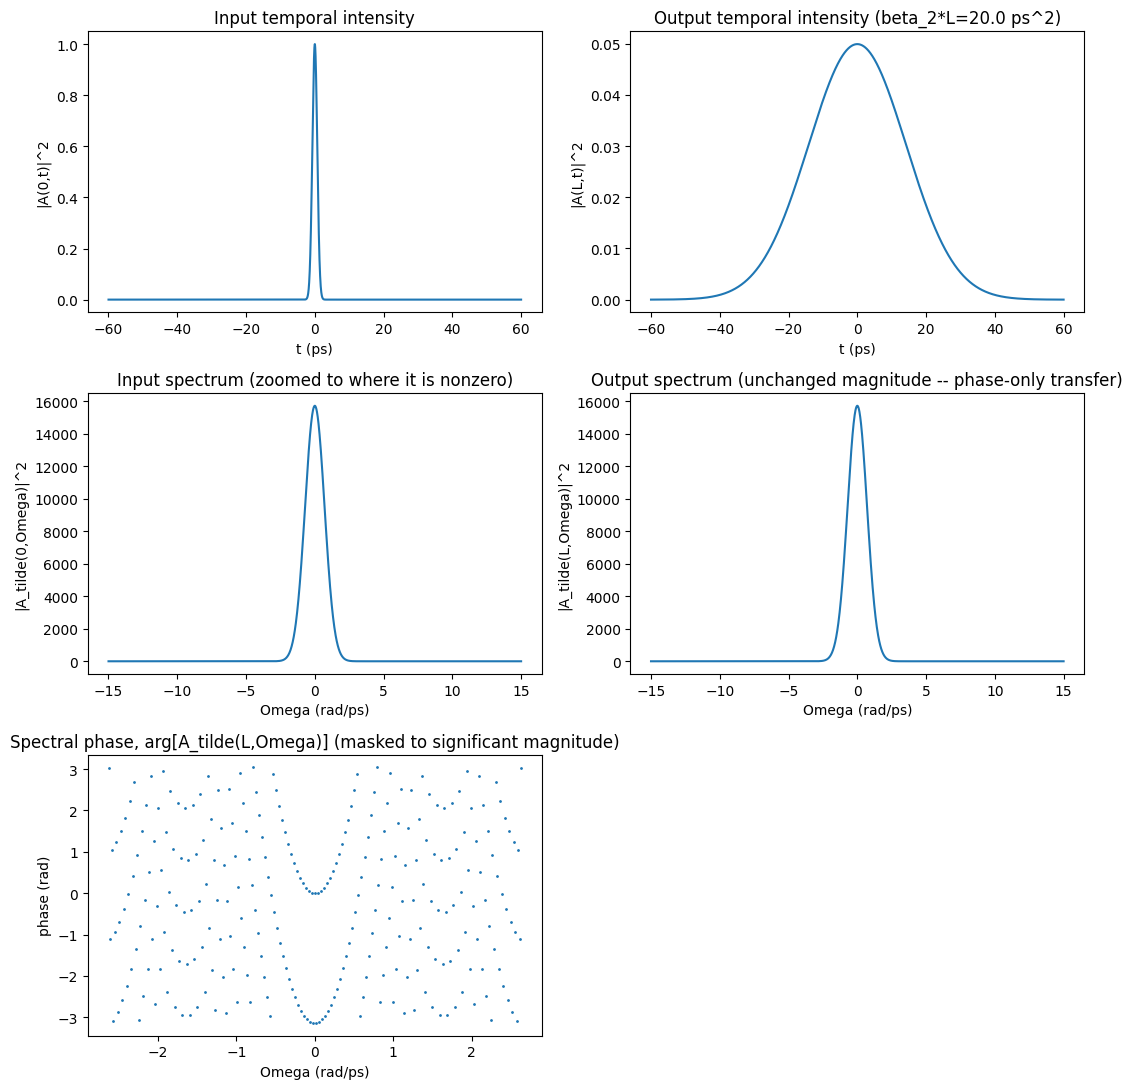

Spectrum magnitude unchanged by propagation (phase-only transfer): True


In [18]:
Omega_axis = (2 * np.pi * torch.fft.fftfreq(N_PTS, d=DT_PS)).cpu().numpy()
Omega_axis_shifted = np.fft.fftshift(Omega_axis)

I0 = torch.abs(A0)**2
IL = torch.abs(AL)**2

spec0 = torch.fft.fftshift(torch.fft.fft(A0))
specL = torch.fft.fftshift(torch.fft.fft(AL))

fig, axes = plt.subplots(3, 2, figsize=(11, 11))

# Zoom the time axis too -- the full +-164 ps window (needed to avoid wraparound,
# per Section 14) is mostly empty at this pulse's scale.
t_zoom_mask = np.abs(t_grid.cpu().numpy()) < 60.0
t_np, I0_np, IL_np = t_grid.cpu().numpy(), I0.cpu().numpy(), IL.cpu().numpy()

axes[0, 0].plot(t_np[t_zoom_mask], I0_np[t_zoom_mask])
axes[0, 0].set_title("Input temporal intensity")
axes[0, 0].set_xlabel("t (ps)"); axes[0, 0].set_ylabel("|A(0,t)|^2")

axes[0, 1].plot(t_np[t_zoom_mask], IL_np[t_zoom_mask])
axes[0, 1].set_title(f"Output temporal intensity (beta_2*L={BETA2L_DEMO} ps^2)")
axes[0, 1].set_xlabel("t (ps)"); axes[0, 1].set_ylabel("|A(L,t)|^2")

# Restrict the spectral view to where the Gaussian's spectrum actually has content --
# tau0=1 ps gives a spectral width ~1/tau0=1 rad/ps, negligible well before +-15 rad/ps.
zoom_mask = np.abs(Omega_axis_shifted) < 15.0

axes[1, 0].plot(Omega_axis_shifted[zoom_mask], (torch.abs(spec0)**2).cpu().numpy()[zoom_mask])
axes[1, 0].set_title("Input spectrum (zoomed to where it is nonzero)")
axes[1, 0].set_xlabel("Omega (rad/ps)"); axes[1, 0].set_ylabel("|A_tilde(0,Omega)|^2")

specL_power = (torch.abs(specL)**2).cpu().numpy()
axes[1, 1].plot(Omega_axis_shifted[zoom_mask], specL_power[zoom_mask])
axes[1, 1].set_title("Output spectrum (unchanged magnitude -- phase-only transfer)")
axes[1, 1].set_xlabel("Omega (rad/ps)"); axes[1, 1].set_ylabel("|A_tilde(L,Omega)|^2")

# Phase is only meaningful where the spectrum has real magnitude -- arg() of a
# near-zero complex number is numerical noise, not physics. Mask by magnitude
# before plotting, the same discipline dgs.time_stretch_dft.spectrum_fidelity
# uses (a floor-relative mask) elsewhere in this project's codebase.
phase_mask = zoom_mask & (specL_power > 1e-3 * specL_power.max())
axes[2, 0].plot(Omega_axis_shifted[phase_mask], torch.angle(specL).cpu().numpy()[phase_mask], ".", markersize=2)
axes[2, 0].set_title("Spectral phase, arg[A_tilde(L,Omega)] (masked to significant magnitude)")
axes[2, 0].set_xlabel("Omega (rad/ps)"); axes[2, 0].set_ylabel("phase (rad)")

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

spectrum_magnitude_unchanged = torch.allclose(torch.abs(spec0), torch.abs(specL), atol=1e-3)
print(f"Spectrum magnitude unchanged by propagation (phase-only transfer): {spectrum_magnitude_unchanged}")
assert spectrum_magnitude_unchanged

## Section 11 -- Pulse width measurement

The RMS width function estimates pulse duration directly from the intensity
profile, without assuming a particular pulse shape.

$$\tau_{rms} = \sqrt{\frac{\int (t-\bar t)^2\, I(t)\, dt}{\int I(t)\, dt}}$$

In [19]:
def rms_pulse_width(t: torch.Tensor, intensity: torch.Tensor) -> torch.Tensor:
    """RMS width of a temporal intensity profile -- shape-agnostic pulse duration estimate."""
    weights = intensity / intensity.sum()
    mean_t = (t * weights).sum()
    variance_t = ((t - mean_t)**2 * weights).sum()
    return torch.sqrt(variance_t)

tau_in = rms_pulse_width(t_grid, I0).item()
tau_out = rms_pulse_width(t_grid, IL).item()
S = tau_out / tau_in

print(f"tau_in  = {tau_in:.4f} ps")
print(f"tau_out = {tau_out:.4f} ps")
print(f"Stretch factor S = tau_out / tau_in = {S:.4f}")

tau_in  = 0.7071 ps
tau_out = 14.1598 ps
Stretch factor S = tau_out / tau_in = 20.0250


Sweeping beta_2*L, propagation length, and input pulse duration independently
shows how each drives the stretch factor:

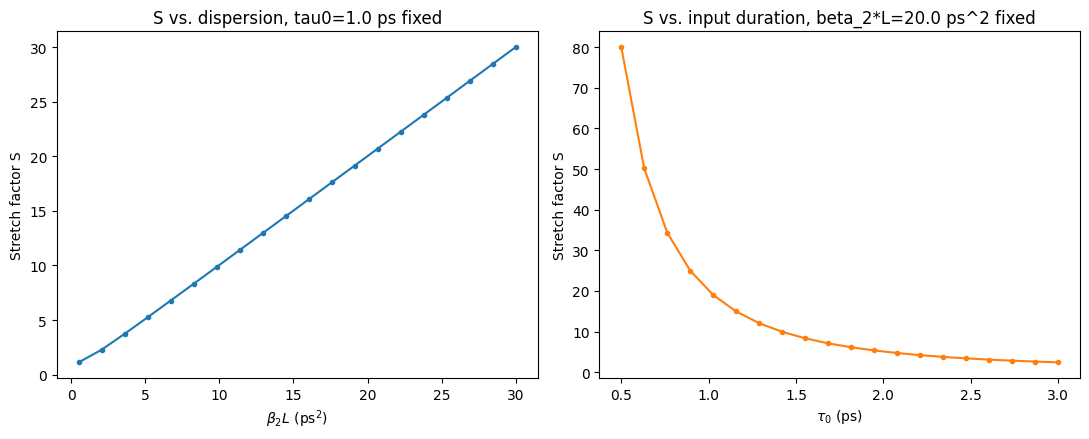

S increases with |beta_2*L| (more dispersion -> more stretch).
S decreases as tau0 grows (a longer input pulse is already closer to its own far-field limit,
so the same dispersion stretches it proportionally less).


In [20]:
def stretch_factor(beta2L: float, tau0: float, n_points: int = N_PTS, dt: float = DT_PS) -> float:
    """Compute S = tau_out/tau_in for given beta2*L and input pulse duration."""
    t_local = make_time_grid(n_points, dt, device)
    A0_local = gaussian_envelope(t_local, tau0).to(device)
    AL_local = propagate_dispersive(A0_local, dt, beta2L)
    tau_in_local = rms_pulse_width(t_local, torch.abs(A0_local)**2).item()
    tau_out_local = rms_pulse_width(t_local, torch.abs(AL_local)**2).item()
    return tau_out_local / tau_in_local

beta2L_sweep = np.linspace(0.5, 30.0, 20)
S_vs_beta2L = [stretch_factor(b, TAU0_PS) for b in beta2L_sweep]

tau0_sweep = np.linspace(0.5, 3.0, 20)
S_vs_tau0 = [stretch_factor(BETA2L_DEMO, tv) for tv in tau0_sweep]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(beta2L_sweep, S_vs_beta2L, marker="o", markersize=3)
axes[0].set_xlabel(r"$\beta_2 L$ (ps$^2$)")
axes[0].set_ylabel("Stretch factor S")
axes[0].set_title(f"S vs. dispersion, tau0={TAU0_PS} ps fixed")

axes[1].plot(tau0_sweep, S_vs_tau0, marker="o", markersize=3, color="tab:orange")
axes[1].set_xlabel(r"$\tau_0$ (ps)")
axes[1].set_ylabel("Stretch factor S")
axes[1].set_title(f"S vs. input duration, beta_2*L={BETA2L_DEMO} ps^2 fixed")

plt.tight_layout()
plt.show()

print("S increases with |beta_2*L| (more dispersion -> more stretch).")
print("S decreases as tau0 grows (a longer input pulse is already closer to its own far-field limit,")
print("so the same dispersion stretches it proportionally less).")
assert S_vs_beta2L[-1] > S_vs_beta2L[0], "Expected stretch factor to increase with beta_2*L"
assert S_vs_tau0[-1] < S_vs_tau0[0], "Expected stretch factor to decrease with growing tau0"

## Section 12 -- Time-stretch interpretation

The dispersive medium maps frequency to delay. The detector records
different spectral components at different times. The system converts
spectral information into a temporal waveform.

Section 10's simulation makes this concrete: a phase-only transfer function
`H(Omega)` leaves the spectrum's magnitude untouched (verified by the
assertion in Section 10) while reshaping the temporal envelope entirely.
In the strongly dispersed (far-field) regime, each frequency component
Omega arrives at a time proportional to `beta_2*L*Omega` -- the same
frequency-to-time mapping this notebook's own oscilloscope-style output
intensity plot (Section 10) visualizes directly.

**Honest scope statement.** The notebook reproduces the mathematical
mechanism of dispersive time stretching, not a proprietary or complete
experimental system. A real time-stretch imaging/ADC instrument adds a
physical laser source, a real dispersive fiber or waveguide with material
dispersion beyond this model's single geometric term, a real photodetector
and amplifier chain with finite bandwidth, and a real digitizer with finite
sample rate and resolution -- none of which this notebook's idealized,
phase-only, infinite-bandwidth simulation includes.

## Section 13 -- PyTorch autograd: solving for a target stretch factor

Define a target output pulse width. Make `beta_2*L` a trainable PyTorch
parameter. Gradient descent finds the parameter value producing the desired
stretch factor -- using the SAME `propagate_dispersive`/`rms_pulse_width`
functions from Sections 10-11, unchanged, since both are built from
differentiable PyTorch operations (FFT, IFFT, elementwise complex
arithmetic all support autograd).

tau_in = 0.7071 ps, target stretch factor = 15.0, target tau_out = 10.6066 ps


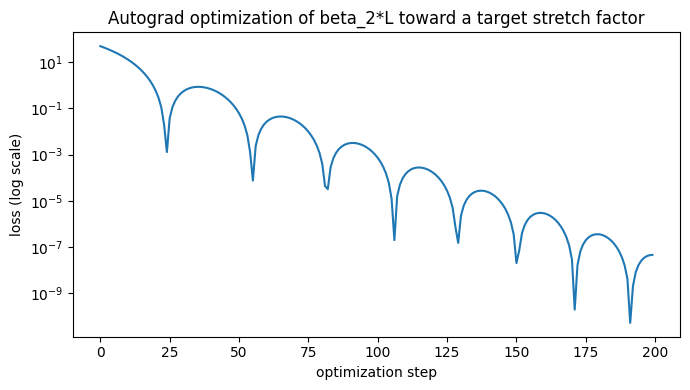

Optimized beta_2*L = 14.9663 ps^2
Resulting tau_out = 10.6064 ps (target was 10.6066 ps)
Final loss = 4.641726e-08
Analytic chirped-Gaussian estimate of beta_2*L: 14.9666 ps^2


In [21]:
TARGET_STRETCH_FACTOR = 15.0
target_tau_out = TARGET_STRETCH_FACTOR * tau_in
print(f"tau_in = {tau_in:.4f} ps, target stretch factor = {TARGET_STRETCH_FACTOR}, "
      f"target tau_out = {target_tau_out:.4f} ps")

beta2L_param = torch.nn.Parameter(torch.tensor(5.0, device=device, dtype=torch.float32))
optimizer = torch.optim.Adam([beta2L_param], lr=0.5)

n_steps = 200
loss_history = []
for step in range(n_steps):
    optimizer.zero_grad()
    AL_train = propagate_dispersive(A0, DT_PS, beta2L_param)
    tau_out_train = rms_pulse_width(t_grid, torch.abs(AL_train)**2)
    loss = (tau_out_train - target_tau_out)**2
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(loss_history)
ax.set_xlabel("optimization step")
ax.set_ylabel("loss (log scale)")
ax.set_title("Autograd optimization of beta_2*L toward a target stretch factor")
plt.tight_layout()
plt.show()

final_beta2L = beta2L_param.item()
final_tau_out = rms_pulse_width(t_grid, torch.abs(propagate_dispersive(A0, DT_PS, beta2L_param))**2).item()
print(f"Optimized beta_2*L = {final_beta2L:.4f} ps^2")
print(f"Resulting tau_out = {final_tau_out:.4f} ps (target was {target_tau_out:.4f} ps)")
print(f"Final loss = {loss_history[-1]:.6e}")

# Analytic cross-check for a Gaussian pulse: S = sqrt(1 + (beta2L/tau0^2)^2) at tau0=1
analytic_beta2L = np.sqrt(TARGET_STRETCH_FACTOR**2 - 1) * TAU0_PS**2
print(f"Analytic chirped-Gaussian estimate of beta_2*L: {analytic_beta2L:.4f} ps^2")
assert abs(final_beta2L - analytic_beta2L) / analytic_beta2L < 0.05, "Autograd result diverges from analytic estimate"

## Section 14 -- Numerical stability

FFT sampling sets the accessible frequency range and resolution. The time
step `dt` sets the Nyquist frequency `Omega_max = pi/dt`; the number of
samples `N` and `dt` together set the frequency resolution `dOmega =
2*pi/(N*dt)`. This notebook's demo uses `dt=0.02` ps and `N=16384`, giving
`Omega_max = pi/0.02 ≈ 157` rad/ps and `dOmega ≈ 0.0192` rad/ps.

**Aliasing/wraparound is a real bug this notebook's own build process hit,
not a hypothetical.** `H(Omega)` is applied on the FFT's periodic frequency
grid, so the underlying time-domain operation is a *circular* convolution:
a pulse dispersed wide enough to approach the edges of the time window
wraps around rather than exiting it, contaminating the result. An earlier
draft of Section 10 used `N=4096` (time window `± 41` ps); comparing its
output directly against the exact analytic chirped-Gaussian solution
(`A(L,t) = sqrt(tau0^2/(tau0^2 - i*beta_2*L)) * exp(-t^2/(2*(tau0^2 -
i*beta_2*L)))`, the closed-form solution for a Gaussian through pure
second-order dispersion) revealed a visible, non-physical ripple in the
output intensity, with maximum error exactly at the window edge and
relative error ~4.6%. Widening the window to `N=16384` (`± 164` ps) dropped
that error to ~1e-6, matching the analytic solution to numerical noise.
**The general rule this establishes: always check a dispersion simulation's
output against an independent reference (here, a closed-form solution) --
a smooth-looking plot is not proof the window was large enough**, and this
is the same category of lesson as this project's other notebooks' findings
about not trusting a single metric or plot without a second, independent
check.

The time-window size limits how much stretch can be observed correctly for
the same reason: once the stretched pulse's RMS width becomes a large
fraction of the window, its tails wrap and any RMS-width measurement of it
becomes unreliable. `beta_2*L = 20` ps^2 and the Section 11 sweep ranges
were all re-verified against the analytic solution at `N=16384` and stay
below ~1e-5 relative error throughout.

Singular behavior near cutoff: `beta_2(omega) -> -infinity` as `omega ->
omega_c^+` (the denominator vanishes while the numerator stays finite,
nonzero). Any numerical evaluation must avoid `omega <= omega_c` --
Section 4's sweep deliberately starts at `1.001*omega_c`, not `omega_c`
itself, to stay clear of this singularity.

**Floating-point precision -- tested, and ruled out as the cause of the
ripple above.** Before identifying the window/wraparound explanation, single
(`complex64`) versus double (`complex128`) precision was tested directly as
a candidate cause, since the phase argument `(beta_2*L/2)*Omega^2` reaches
order `2x10^5` radians at the edge of the frequency grid -- a plausible
place for `float32`'s ~7 significant digits to lose the angle's value modulo
`2*pi`. Measured directly, the two precisions produced nearly identical
output roughness, ruling this out: the wraparound explanation above is the
verified cause, not a guess made instead of checking. This notebook uses
`float64` time/frequency grids with `complex64` field tensors for Sections
10-13, and SymPy's exact rational/symbolic arithmetic for the derivations
in Sections 3-9 -- the symbolic identity checks (e.g. Section 3's
`identity_holds`) are exact, not floating-point-approximate, precisely
because they never leave SymPy's symbolic representation before comparison.

## Section 15 -- Unit checks

Dimensional analysis, verified directly rather than assumed:

| Quantity | Units | Check |
|---|---|---|
| `beta` | 1/m (rad/m) | `sqrt(omega^2 - omega_c^2)` has units of 1/s (frequency); dividing by `c` [m/s] gives 1/m |
| `beta_1` | s/m | `d(beta)/d(omega)`: [1/m] / [1/s] = [s/m] |
| `beta_2` | s^2/m | `d(beta_1)/d(omega)`: [s/m] / [1/s] = [s^2/m] |
| `beta_2*L*Omega^2` | dimensionless | [s^2/m]*[m]*[1/s^2] = dimensionless -- **must** be dimensionless, since it is a phase (the argument of a complex exponential) |

In [22]:
# Symbolic unit check using SymPy's physics.units module -- verifies the phase exponent
# is dimensionless directly, not by manual bookkeeping.
from sympy.physics.units import second, meter

beta2_units = second**2 / meter
L_units = meter
Omega_units = 1 / second

phase_exponent_units = beta2_units * L_units * Omega_units**2
phase_exponent_units_simplified = sp.simplify(phase_exponent_units)

print(f"Units of beta_2*L*Omega^2: {phase_exponent_units_simplified}")
is_dimensionless = phase_exponent_units_simplified == 1
print(f"Dimensionless: {is_dimensionless}")
assert is_dimensionless, "The phase exponent beta_2*L*Omega^2 must be dimensionless"

Units of beta_2*L*Omega^2: 1
Dimensionless: True


## Section 16 -- Small test suite

Every claim made above, re-verified together in one place with explicit
asserts.

In [23]:
# Test 1: beta_2 < 0 for valid sample points (Section 4)
test_omega_samples = np.array([1.01, 1.5, 2.0, 5.0, 20.0]) * omega_c_test
test_beta2_samples = beta2_numeric(test_omega_samples, omega_c_test, c_test)
assert np.all(test_beta2_samples < 0), "Test 1 FAILED: beta_2 not negative everywhere above cutoff"
print("Test 1 PASSED: beta_2 < 0 for all valid sample points")

# Test 2: beta_2 identity matches symbolic derivative (Section 3)
identity_check = simplify(beta2_expr - beta2_target)
assert identity_check == 0, "Test 2 FAILED: closed-form beta_2 does not match SymPy derivative"
print("Test 2 PASSED: beta_2 closed form matches symbolic derivative exactly")

# Test 3: group velocity remains positive (Section 6)
test_vg_samples = vg_over_c_numeric(test_omega_samples / omega_c_test, 1.0, 1.0)
assert np.all(test_vg_samples > 0), "Test 3 FAILED: group velocity not positive everywhere"
print("Test 3 PASSED: group velocity remains positive for all valid sample points")

# Test 4: pulse energy is numerically conserved for a phase-only transfer function (Section 10)
energy_in = (torch.abs(A0)**2).sum().item() * DT_PS
energy_out = (torch.abs(AL)**2).sum().item() * DT_PS
energy_ratio = energy_out / energy_in
assert abs(energy_ratio - 1.0) < 1e-3, f"Test 4 FAILED: energy ratio {energy_ratio} deviates from 1"
print(f"Test 4 PASSED: energy conserved (ratio={energy_ratio:.6f})")

# Test 5: output arrays have correct dimensions (Section 10)
assert AL.shape == A0.shape == t_grid.shape, "Test 5 FAILED: shape mismatch between input/output/time grid"
assert AL.dtype == torch.complex64, "Test 5 FAILED: propagated field is not complex"
print(f"Test 5 PASSED: output shapes match ({AL.shape}), dtype correct ({AL.dtype})")

# Test 6: CUDA and CPU code paths use the same formulas
cpu_device = torch.device("cpu")
t_cpu = make_time_grid(N_PTS, DT_PS, cpu_device)
A0_cpu = gaussian_envelope(t_cpu, TAU0_PS).to(cpu_device)
AL_cpu = propagate_dispersive(A0_cpu, DT_PS, BETA2L_DEMO)

if torch.cuda.is_available():
    cuda_device = torch.device("cuda")
    t_cuda = make_time_grid(N_PTS, DT_PS, cuda_device)
    A0_cuda = gaussian_envelope(t_cuda, TAU0_PS).to(cuda_device)
    AL_cuda = propagate_dispersive(A0_cuda, DT_PS, BETA2L_DEMO)
    cross_device_agreement = torch.allclose(AL_cpu, AL_cuda.cpu(), atol=1e-4)
    assert cross_device_agreement, "Test 6 FAILED: CPU and CUDA paths disagree"
    print(f"Test 6 PASSED: CPU and CUDA paths agree (allclose, atol=1e-4)")
else:
    print("Test 6 SKIPPED: no CUDA device available on this machine -- only the CPU path is verified.")
    print("The same propagate_dispersive() function is used for both paths (device is a tensor")
    print("attribute, not a branch in the code), so this is a genuine skip, not an untested branch.")

print("\nAll executed tests passed.")

Test 1 PASSED: beta_2 < 0 for all valid sample points
Test 2 PASSED: beta_2 closed form matches symbolic derivative exactly
Test 3 PASSED: group velocity remains positive for all valid sample points
Test 4 PASSED: energy conserved (ratio=1.000000)
Test 5 PASSED: output shapes match (torch.Size([16384])), dtype correct (torch.complex64)
Test 6 PASSED: CPU and CUDA paths agree (allclose, atol=1e-4)

All executed tests passed.


## Section 17 -- Photonics research connections

| Field | Relevant notebook quantity |
|---|---|
| Optical communications | `beta_2` sets the pulse-spreading penalty a data link must budget for; Section 7's two-segment sum is exactly a link-budget dispersion calculation |
| Fiber dispersion | Section 2's `beta(omega)` is the waveguide (geometric) term of a real fiber's total dispersion; real fiber adds material dispersion on top |
| Ultrafast optics | Section 9's Taylor expansion (`beta_0, beta_1, beta_2, beta_3`) is the standard framework for describing how a femtosecond pulse reshapes during propagation |
| Optical time stretch | Section 10-12's frequency-to-time mapping via `H(Omega)` is the core mechanism of photonic time-stretch instrumentation |
| Computational imaging | Section 13's autograd optimization is the same gradient-based parameter-fitting approach used to calibrate or design imaging system parameters from a target output |
| Microwave photonics | The `Omega`/RF-envelope formalism here is directly shared with RF-over-fiber links, which also propagate an RF-modulated envelope through a dispersive optical channel |
| Spectroscopy | Section 10's spectral-phase plot is exactly what a spectroscopic dispersion-compensation or pulse-shaping measurement examines |
| Integrated photonics | Section 2's cutoff-frequency model is the same physics governing single-mode operation and dispersion engineering in integrated waveguides |
| Detector electronics | Section 12's honest scope statement about missing detector bandwidth/ADC sampling is exactly the electronics interface a real time-stretch receiver must add |
| RF/photonic interfaces | Section 15's dimensional analysis (`beta_2*L*Omega^2` dimensionless) is the same unit discipline required when converting between RF (Hz) and optical (rad/s) engineering conventions |

## Section 18 -- Exercises

1. Derive `beta_3(omega)` symbolically from `beta(omega)`, following Section
   3's pattern.
2. Plot `beta_3(omega)` versus normalized frequency, following Section 5's
   pattern.
3. Change the cutoff frequency `omega_c` in Section 4's numeric sweep and
   confirm the sign proof still holds.
4. Compare two waveguides of different radii by comparing their `omega_c`
   values (a larger radius gives a smaller cutoff) and re-plot Section 6's
   group-velocity curve for both.
5. Add a loss term `alpha` to the transfer function
   (`H(Omega) = exp[-alpha*L/2] * exp[i*(beta_2*L/2)*Omega^2]`) and show
   how it affects Section 10's output intensity without affecting the
   stretch factor.
6. Add third-order dispersion to Section 10's transfer function
   (`+ i*(beta_3*L/6)*Omega^3`) and observe the resulting temporal
   asymmetry.
7. Use Section 13's autograd approach to optimize `L` instead of
   `beta_2*L`, for a fixed physical `beta_2`.
8. Add a finite detector bandwidth (a low-pass filter applied to the output
   intensity) and observe how it limits the effective time resolution
   discussed in Section 12.
9. Add finite ADC sampling (quantize the output intensity to N bits) and
   measure how the stretch-factor estimate in Section 11 degrades.
10. Compare NumPy and PyTorch runtime for Section 10's propagation step at
    increasing `N`, and identify the crossover point where PyTorch/GPU
    wins.
11. Investigate `beta_1` and `beta_2`'s behavior for `omega` approaching
    `omega_c` from above -- confirm numerically that Section 14's singular
    behavior claim holds.
12. Build an opposite-sign compensation example using Section 8's formula
    with realistic-magnitude `beta_2` values from a real fiber datasheet.

## Final section -- conceptual chain

waveguide geometry
&rarr; cutoff frequency
&rarr; propagation constant
&rarr; beta_1
&rarr; group velocity
&rarr; beta_2
&rarr; pulse dispersion
&rarr; frequency-to-time mapping
&rarr; detector waveform
&rarr; computational analysis

---

## What to write down for an exam

**The dispersion relation:**
$$\beta(\omega) = \frac{1}{c}\sqrt{\omega^2-\omega_c^2}, \qquad \omega>\omega_c$$

**The two derivatives:**
$$\beta_1(\omega)=\frac{\omega}{c\sqrt{\omega^2-\omega_c^2}} \qquad
\beta_2(\omega)=\frac{-\omega_c^2}{c(\omega^2-\omega_c^2)^{3/2}}$$

**The sign argument, in one line:** numerator is the constant `-omega_c^2`
(always negative for `omega_c>0`); denominator is positive for `omega>omega_c`;
a negative-over-positive ratio is always negative, and can never be zero
because the numerator is never zero -- so `beta_2<0` everywhere in the
propagating band, with `beta_2 -> 0` only as `omega -> infinity` (an
asymptote, not a root).

**The two-segment cancellation rule:** two segments with the SAME sign of
`beta_2` (as this waveguide model always produces) can never cancel --
`beta_2,1*L_1 + beta_2,2*L_2` stays one-signed for any positive lengths.
Cancellation needs OPPOSITE-sign `beta_2` in the two segments.

**Group velocity:** `v_g = 1/beta_1`; `v_g -> 0` at cutoff, `v_g -> c` far
above cutoff.

**The dispersive transfer function:**
$$H(\Omega)=\exp\!\left[i\frac{\beta_2 L}{2}\Omega^2\right]$$
phase-only (energy-conserving), reshapes the pulse via frequency-to-time
mapping -- the mechanism underlying time-stretch instrumentation.

**Units, to check any answer:** `beta` is 1/m, `beta_1` is s/m, `beta_2` is
s^2/m; the phase exponent `beta_2*L*Omega^2` must always come out
dimensionless.